In [52]:
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import seaborn as sns

display(
    HTML(
        "<style>.output_png, .cell-output-display { display: flex; justify-content: center; }</style>"
    )
)

In [24]:
import pandas as pd

df = pd.read_csv("podatki/evrovizija.csv")
podatki_po_uvedbi_polfinala = df [df ["leto"] >= 2004]
tabela_po_2016 = df [df ["leto"] >= 2016]


In [43]:
df[df["leto"] == 2007]

,leto,mesto,drzava,pesem,izvajalec,tocke,tocke_publike,tocke_zirije,startna_stevilka,st_dvanajstk
976,2007,1,Serbia,Molitva,Marija Šerifović,268.0,NaN,NaN,17,NaN
977,2007,2,Ukraine,Dancing Lasha Tumbai,Verka Serduchka,235.0,NaN,NaN,18,NaN
978,2007,3,Russia,Song # 1,Serebro,207.0,NaN,NaN,15,NaN
979,2007,4,Turkey,Shake It Up Şekerim,Kenan Doğulu,163.0,NaN,NaN,22,NaN
980,2007,5,Bulgaria,Water,Elitsa Todorova & Stoyan Yankulov,157.0,NaN,NaN,21,NaN
981,2007,6,Belarus,Work Your Magic,Dmitry Koldun,145.0,NaN,NaN,3,NaN
982,2007,7,Greece,Yassou Maria,Sarbel,139.0,NaN,NaN,10,NaN
983,2007,8,Armenia,Anytime You Need,Hayko,138.0,NaN,NaN,23,NaN
984,2007,9,Hungary,Unsubstantial Blues,Magdi Rúzsa,128.0,NaN,NaN,8,NaN
985,2007,10,Moldova,Fight,Natalia Barbu,109.0,NaN,NaN,24,NaN


**Osnovno**

In [60]:
def stevilo_izvedb (datoteka):
    df = pd.read_csv (datoteka)
    return df ["leto"].nunique ()

st_izvedb = stevilo_izvedb ("podatki/evrovizija.csv")
print (f"Do sedaj se je izvedlo {st_izvedb} izvedb tekmovanja za pesem Evrovizije.")

Do sedaj se je izvedlo 70 izvedb tekmovanja za pesem Evrovizije.


In [18]:
def stevilo_finalistov (datoteka, izbrano_leto):
    if izbrano_leto == 1956:
        return 14
    elif izbrano_leto not in range(1956, 2027):
        return None 
    
    finalisti = datoteka [datoteka ["leto"] == izbrano_leto]
    return len (finalisti)

leto = 1957
st = stevilo_finalistov (df, leto)

if st is None:
    print (f"Izbranega leta ni bilo tekmovanja za pesem Evrovizije. Izberite drugo leto!")
else: 
    print (f"Leta {leto} je bilo v finalu {st} nastopajočih držav.")

Leta 1957 je bilo v finalu 10 nastopajočih držav.


In [23]:
def kolikokrat_je_bila_drzava_v_finalu (datoteka):
    rezultat = datoteka ["drzava"].value_counts ().reset_index ()
    rezultat.columns = ["Država", "Število nastopov v finalu"]
    rezultat.index = range (1, len (rezultat) + 1)

    return rezultat

tabela_nastopov = kolikokrat_je_bila_drzava_v_finalu (podatki_po_uvedbi_polfinala)
print (tabela_nastopov)

                  Država  Število nastopov v finalu
1                Germany                         22
2                 France                         22
3         United Kingdom                         22
4                 Sweden                         21
5                  Spain                         21
6                Ukraine                         20
7                 Greece                         19
8                 Norway                         19
9                 Russia                         15
10               Romania                         15
11                Israel                         15
12             Lithuania                         15
13                 Italy                         15
14               Moldova                         14
15               Denmark                         14
16               Finland                         14
17               Armenia                         14
18                Serbia                         14
19          

**Zmagovalci**

In [44]:
def stevilo_zmag (podatki):
    """Funkcija vrne tabelo držav in število njihovih dosedanjih zmag, pri čemer države z 0 zmagami ignorira."""
    df = pd.read_csv (podatki)
    zmagovalci = df [df ["mesto"] == 1]

    tabela = zmagovalci ['drzava'].value_counts ().reset_index ()
    tabela.columns = ["Država", "Število dosedanjih zmag"]
    tabela.index = range (1, len (tabela) + 1)

    return tabela 
    
rezultat = stevilo_zmag ("podatki/evrovizija.csv")
print (rezultat)

            Država  Število dosedanjih zmag
1          Ireland                        7
2           Sweden                        7
3      Netherlands                        5
4           France                        5
5       Luxembourg                        5
6   United Kingdom                        5
7           Israel                        4
8      Switzerland                        3
9          Denmark                        3
10           Italy                        3
11         Austria                        3
12          Norway                        3
13         Ukraine                        3
14           Spain                        2
15         Germany                        2
16          Monaco                        1
17         Belgium                        1
18      Yugoslavia                        1
19         Estonia                        1
20          Latvia                        1
21          Turkey                        1
22          Greece              

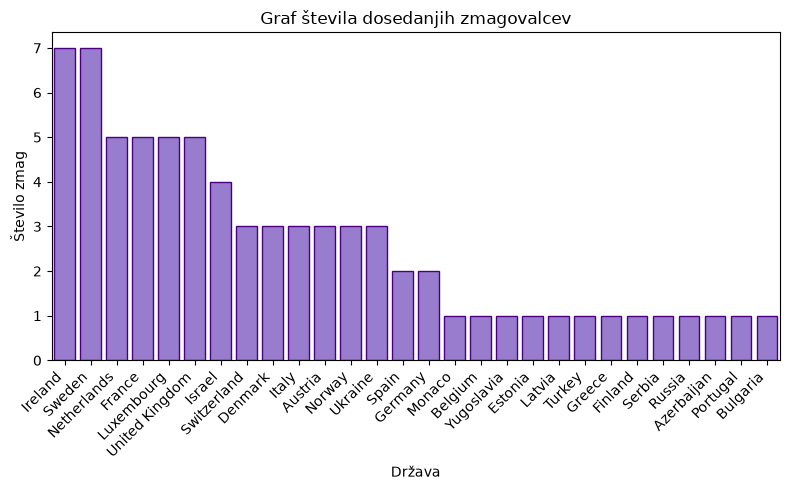

In [59]:
plt.figure (figsize = (8,5))

sns.barplot (
    data = rezultat, 
    x = "Država",
    y = "Število dosedanjih zmag",
    color = "mediumpurple",
    edgecolor = "indigo"
    )

plt.title ("Graf števila dosedanjih zmagovalcev")
plt.xlabel ("Država")
plt.ylabel ("Število zmag")

plt.xticks (rotation = 45, ha = "right")

plt.tight_layout ()
plt.show ()

In [ ]:
def najvec_tock_po_ziriji (datoteka):
    max_st_tock = -1
    maksimalen = None

    for indeks, vrstica in tabela_po_2016.iterrows ():
        if vrstica ["tocke_publike"] > max_st_tock:
            max_st_tock = vrstica ["tocke_publike"]
            maksimalen = vrstica

    rezultat = maksimalen [["leto", "drzava", "izvajalec", "tocke_publike"]]
    rezultat.index = ["Leto", "Država", "Izvajalec", "Točke publike"]
    return rezultat

print (najvec_tock_po_ziriji (tabela_po_2016))

      Leto   Država         Izvajalec  Točke publike
1335  2022  Ukraine  Kalush Orchestra          439.0
